In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_cleaned.csv to heart_disease_cleaned.csv


In [ ]:
#importing all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor, BaggingClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report ,mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb

Dataset looking at the columns, shape, and etc

# Reading in Dataset

In [ ]:
import pandas as pd
import io

df = pd.read_csv('heart_disease_cleaned.csv')

In [ ]:
#Lets look at the shape and general info on this dataset

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## DataFrame shape and Patient Id's

In [ ]:
# gives more information on the datatype of each column
df.info

<bound method DataFrame.info of       id  age     sex        dataset               cp  trestbps   chol    fbs  \
0      1   63    Male      Cleveland   typical angina    145.00  233.0   True   
1      2   67    Male      Cleveland     asymptomatic    160.00  286.0  False   
2      3   67    Male      Cleveland     asymptomatic    120.00  229.0  False   
3      4   37    Male      Cleveland      non-anginal    130.00  250.0  False   
4      5   41  Female      Cleveland  atypical angina    130.00  204.0  False   
..   ...  ...     ...            ...              ...       ...    ...    ...   
914  916   54  Female  VA Long Beach     asymptomatic    127.00  333.0   True   
915  917   62    Male  VA Long Beach   typical angina    143.06  139.0  False   
916  918   55    Male  VA Long Beach     asymptomatic    122.00  223.0   True   
917  919   58    Male  VA Long Beach     asymptomatic    150.81  385.0   True   
918  920   62    Male  VA Long Beach  atypical angina    120.00  254.0  False   

              restecg  thalch  exang  oldpeak        slope   ca  \
0      lv hypertrophy  150.00  False    2.300  downsloping  0.0   
1      lv hypertrophy  108.00   True    1.500         flat  3.0   
2      lv hypertrophy  129.00   True    2.600         flat  2.0   
3              normal  187.00  False    3.500  downsloping  0.0   
4      lv hypertrophy  172.00  False    1.400    upsloping  0.0   
..                ...     ...    ...      ...          ...  ...   
914  st-t abnormality  154.00  False    0.000         flat  0.0   
915  st-t abnormality  119.94   True    2.042         flat  0.0   
916  st-t abnormality  100.00  False    0.000         flat  1.0   
917    lv hypertrophy  110.63   True    2.181         flat  0.0   
918    lv hypertrophy   93.00   True    0.000         flat  1.0   

                  thal  num  
0         fixed defect    0  
1               normal    2  
2    reversable defect    1  
3               normal    0  
4               normal    0  
..                 ...  ...  
914             normal    1  
915  reversable defect    0  
916       fixed defect    2  
917  reversable defect    0  
918  reversable defect    1  

[919 rows x 16 columns]>

In [ ]:
df.shape

(919, 16)

In [ ]:
df['id'].min(), df['id'].max()

(1, 920)

A bit interesting to note. This means there are 920 id's so  920 people but the actual row count is 919.  Maybe one of the ids are missing cause the id's range from 1 - 920

In [ ]:
# create the full set of expected IDs
all_ids = set(range(1, 921))

# grab the IDs actually present
present = set(df['id'])

# compute the “missing” ones
missing = all_ids - present

if missing:
    print(f"Missing IDs ({len(missing)}):", sorted(missing))
else:
    print("No IDs missing—1 through 920 are all present.")

# yep one of the ids are missing 754 which is why the shape wasn't lining up with id row

Missing IDs (1): [754]


##General Data Analysis

### Age and Sex Column
getting general data

In [ ]:
# age range  28 to 77
df['age'].min(), df['age'].max()

(28, 77)

In [ ]:
# average age is 53
np.mean(df['age'])

np.float64(53.50924918389554)

Mean: 53.50924918389554
Median: 54.0
Mode: 54


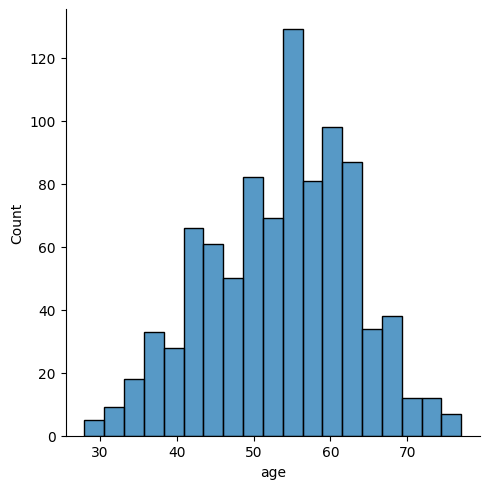

In [ ]:
# want to see how the data is distributed age wise
sns.displot(df['age'])

# print the value of mean, median and mode of age column
print('Mean:', df['age'].mean())
print('Median:', df['age'].median())
print('Mode:', df['age'].mode()[0])

In [ ]:
# now the sex column
df['sex'].value_counts()

,count
sex,
Male,725
Female,194


The amount of data, so disparity, between the data point for sex is worrying. Best to take note of and anaylze the data as necessary since the female sample is much smaller which can lead to skewed results if the the female counts aren't distributed

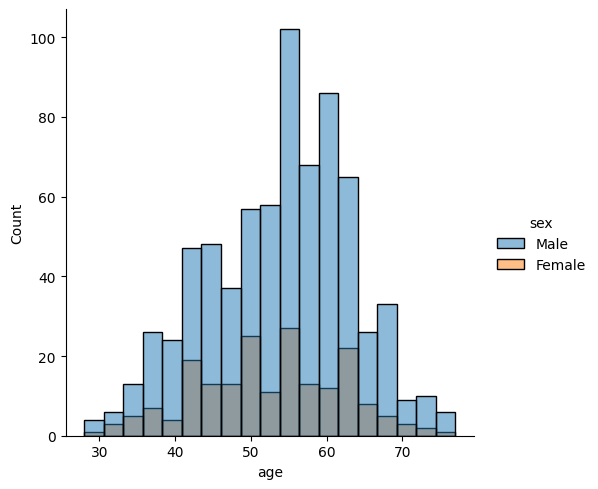

In [ ]:
sns.displot(
    data = df,
    x = 'age',
    hue = 'sex',
    kind = 'hist'
)

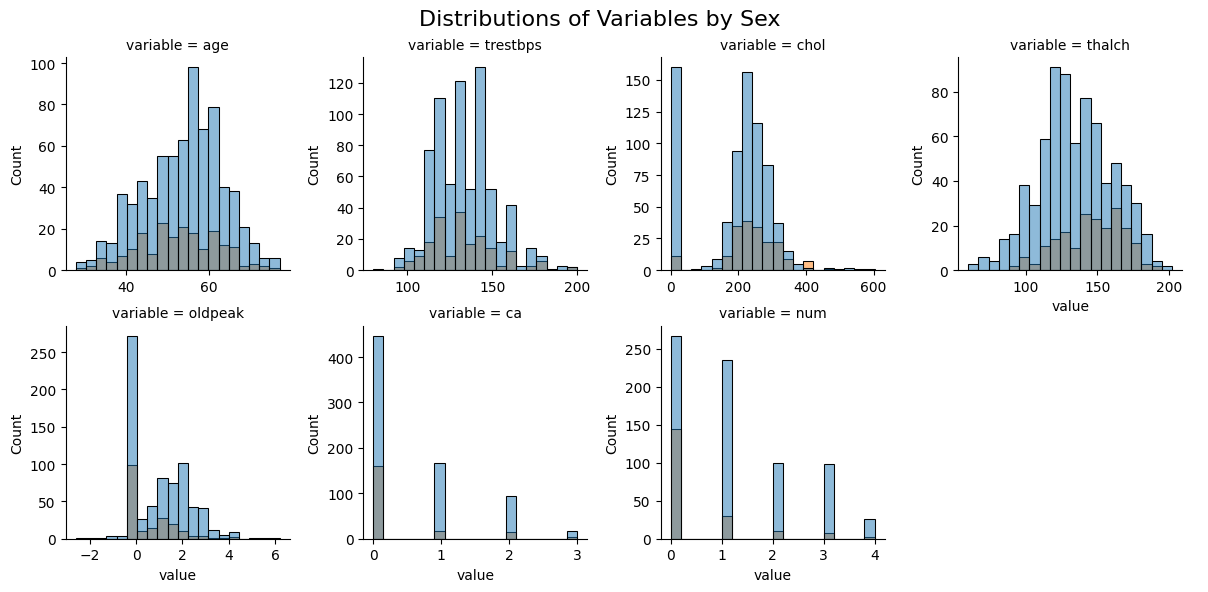

In [ ]:
ignore = ['id', 'sex', 'dataset', 'cp', 'fbs', 'restecg',
          'exang', 'slope', 'thal']

# Only the columns you care about
vars_to_plot = [c for c in df.columns if c not in ignore]

df_long = df.melt(id_vars='sex', value_vars=vars_to_plot,
                  var_name='variable', value_name='value')

# Create the grid with independent axes
g = sns.FacetGrid(
    df_long,
    col='variable',
    col_wrap=4,
    sharex=False,
    sharey=False,
    height=3,
    aspect=1
)

# Map histograms onto it
g.map_dataframe(
    sns.histplot,
    x='value',
    hue='sex',
    multiple='layer',
    bins=20,
    alpha=0.5
)

# Tidy up
g.add_legend()
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Distributions of Variables by Sex", fontsize=16)
plt.show()



#Missing Data


Thankfully this dataset was already cleaned so there is no missing data. Otherwise we would have to remove the missing values or replace it with another value, such as the mean value for that column.

In [ ]:
df.isnull().sum()
# reminds me of R and this gives the missing data per column

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


In [ ]:
df.isnull().sum().sum()
#this gives whether the entire dataset has missing values or not

np.int64(0)

###Outliers
Need to look at the values here.


# Models



In [ ]:
df.head()

#don't use linear regression the num column is not a continuous variable

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
pd.unique(df['num']) # as shown here

array([0, 2, 1, 3, 4])

## Logistic Regression


Let's just make a basic one, say using all the variables well except like ID. The other variables we can use.

## Logisitic Regression
This one does not work, binary model

In [ ]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")

X = df.drop(['num', 'id'], axis=1)
X = pd.get_dummies(X, drop_first=True)

y = df['num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

modelLog= LogisticRegression()
modelLog.fit(X_train, y_train)

y_pred = modelLog.predict(X_test)
print(classification_report(y_test, y_pred))

coed_df = pd.DataFrame ({
    'Feature' : X_train.columns,
    'Coefficient' : modelLog.coef_[0]
})

coef_df = coed_df.sort_values('Coefficient')

plt.figure(figsize=(8, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Effects on Log-Odds')
plt.grid(True)
plt.tight_layout()
plt.show()

#default confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

#confusion matric threshold changed, (0.3 = 0.55, 0.45 = 0.51)
threshold = 0.2# try higher threshold to test effect

# Apply threshold across all classes
max_probs = probs.max(axis=1)
y_pred_custom = np.full_like(max_probs, -1, dtype=int)  # default to -1 (rejection)

confident_enough = max_probs >= threshold
y_pred_custom[confident_enough] = probs.argmax(axis=1)[confident_enough]

print(classification_report(y_test, y_pred_custom))

valid_idx = y_pred_custom != -1
cm_3 = confusion_matrix(y_test[valid_idx], y_pred_custom[valid_idx])

plt.figure(figsize=(6,4))
sns.heatmap(cm_3, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

           0       0.75      0.85      0.80        96
           1       0.48      0.57      0.52        72
           2       0.56      0.17      0.26        29
           3       0.56      0.50      0.53        28
           4       0.00      0.00      0.00         5

    accuracy                           0.62       230
   macro avg       0.47      0.42      0.42       230
weighted avg       0.60      0.62      0.59       230



NameError: name 'plt' is not defined

In [ ]:
#stepwise selection, pointless against the model we used it in
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

sfs = SequentialFeatureSelector(LogisticRegression(),
                                 k_features='best',
                                 forward=True,
                                 floating=False,
                                 scoring='accuracy',
                                 cv=5)

sfs.fit(X_train, y_train)
print(sfs.k_feature_names_)

selected_features = list(sfs.k_feature_names_)
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

modelStepWise = modelLog.fit(X_train_selected, y_train)
y=predStepWise = modelStepWise.predict(X_test_selected)
accuracy_score(y_test, y_pred)

NameError: name 'X_train' is not defined

## Logistic Regression - Ordinal : Num[0-4]


Optimization terminated successfully.
         Current function value: 0.872490
         Iterations: 121
         Function evaluations: 125
         Gradient evaluations: 125
Accuracy: 0.5695652173913044
              precision    recall  f1-score   support

           0       0.75      0.82      0.78        96
           1       0.43      0.51      0.47        72
           2       0.33      0.03      0.06        29
           3       0.40      0.50      0.44        28
           4       0.00      0.00      0.00         5

    accuracy                           0.57       230
   macro avg       0.38      0.37      0.35       230
weighted avg       0.54      0.57      0.54       230

                             OrderedModel Results                             
Dep. Variable:                    num   Log-Likelihood:                -601.15
Model:                   OrderedModel   AIC:                             1252.
Method:            Maximum Likelihood   BIC:                          

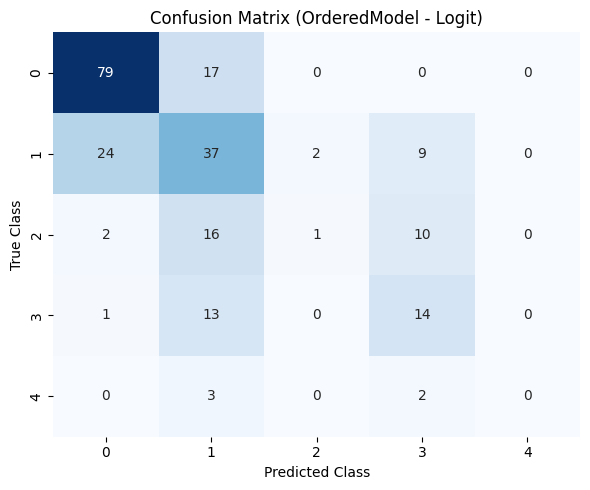

In [ ]:
# accuracy and win recall and loss recall, best to have more false positives?
#correlation graph, confusion matrix
from statsmodels.miscmodels.ordinal_model import OrderedModel


dfModel = pd.DataFrame(df)

X = dfModel.drop(['num', 'id'], axis=1)
y = dfModel['num']

X = pd.get_dummies(X, drop_first=True)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


# Fit the model
model = OrderedModel(y_train, X_train, distr='logit')
result = model.fit(method='bfgs')

# Predict probabilities
y_pred_probs = result.predict(X_test)

# Get most likely class
y_pred_class = y_pred_probs.idxmax(axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_class))
print(classification_report(y_test, y_pred_class))
print(result.summary())

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_class)

# Plot the heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix (OrderedModel - Logit)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()


###Correlations, Checking for multicollinearity


          Feature_1                 Feature_2  Correlation
419     thal_normal    thal_reversable defect     0.837984
375      slope_flat           slope_upsloping     0.834782
52             chol       dataset_Switzerland     0.713098
331  restecg_normal  restecg_st-t abnormality     0.579752
102          thalch           slope_upsloping     0.482621
187        sex_Male               thal_normal     0.451240
103          thalch               thal_normal     0.428851
101          thalch                slope_flat     0.416653
124           exang               thal_normal     0.414196
111           exang                   oldpeak     0.414196
       Feature_1               Feature_2  Correlation
419  thal_normal  thal_reversable defect     0.837984
375   slope_flat         slope_upsloping     0.834782
52          chol     dataset_Switzerland     0.713098


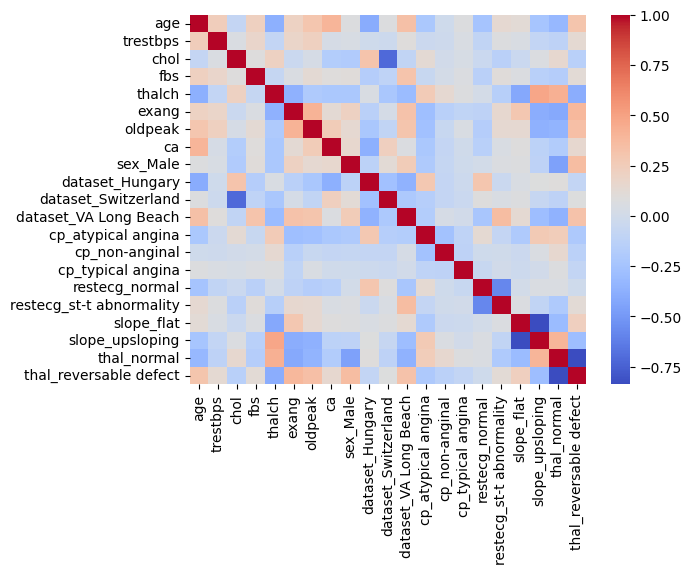

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, cmap='coolwarm')

import pandas as pd
import numpy as np

# Compute correlation matrix
corr_matrix = X_train.corr()

# Unstack to get all pairs, and reset index
corr_pairs = corr_matrix.abs().unstack().reset_index()
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Remove self-correlations
corr_pairs = corr_pairs[corr_pairs['Feature_1'] != corr_pairs['Feature_2']]

# Drop duplicate pairs (e.g., (A,B) and (B,A))
corr_pairs['Pair'] = corr_pairs.apply(lambda row: tuple(sorted([row['Feature_1'], row['Feature_2']])), axis=1)
corr_pairs = corr_pairs.drop_duplicates('Pair').drop(columns='Pair')

# Sort by correlation descending
high_corr = corr_pairs.sort_values(by='Correlation', ascending=False)

# Show top N most correlated pairs
print(high_corr.head(10))

# Get only pairs with correlation > 0.8
high_corr_filtered = high_corr[high_corr['Correlation'] > 0.7]
print(high_corr_filtered)


### Removed based on multicollinearity and p-values

In [ ]:
X_train.columns

X_train_multi = X_train.drop(['dataset_Switzerland', 'slope_upsloping','thal_reversable defect','restecg_normal','fbs','age'], axis = 1)
X_test_multi = X_test.drop(['dataset_Switzerland', 'slope_upsloping','thal_reversable defect','restecg_normal','fbs','age'], axis = 1)

modelMulti = OrderedModel(y_train, X_train_multi, distr='logit') #logit
modelMultiPro = OrderedModel(y_train, X_train_multi, distr='probit') #probit

resultMulti = modelMulti.fit(method='bfgs')
resultMultiPro = modelMultiPro.fit(method='bfgs')

# Predict probabilities
y_multi= resultMulti.predict(X_test_multi)
y_multi_pro= resultMultiPro.predict(X_test_multi)

# Get most likely class
y_multi_class = y_multi.idxmax(axis=1)
y_multi_pro_class = y_multi_pro.idxmax(axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_multi_class))
print("Accuracy:", accuracy_score(y_test, y_multi_pro_class))

print(classification_report(y_test, y_multi_class))
print(classification_report(y_test, y_multi_pro_class))

print(resultMulti.summary())

Optimization terminated successfully.
         Current function value: 0.898803
         Iterations: 87
         Function evaluations: 91
         Gradient evaluations: 91
Optimization terminated successfully.
         Current function value: 0.902639
         Iterations: 62
         Function evaluations: 66
         Gradient evaluations: 66
Accuracy: 0.5695652173913044
Accuracy: 0.5826086956521739
              precision    recall  f1-score   support

           0       0.75      0.77      0.76        96
           1       0.44      0.57      0.50        72
           2       0.00      0.00      0.00        29
           3       0.42      0.57      0.48        28
           4       0.00      0.00      0.00         5

    accuracy                           0.57       230
   macro avg       0.32      0.38      0.35       230
weighted avg       0.50      0.57      0.53       230

              precision    recall  f1-score   support

           0       0.75      0.79      0.77        96


### Feature Map

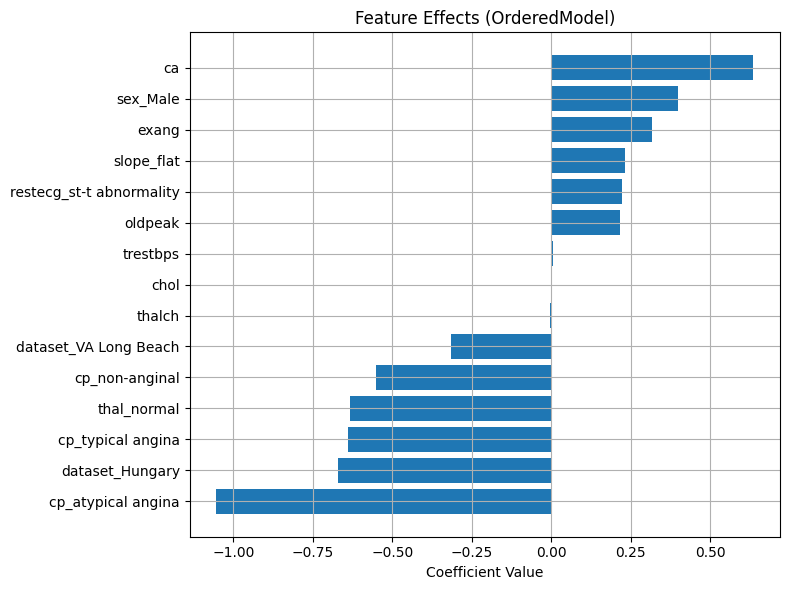

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract coefficients from resultMultiPro
# resultMultiPro.params includes both feature coefficients and thresholds (cutpoints)
# So we filter only the features using X_train.columns
coef_series = resultMultiPro.params[X_train_multi.columns]

# Build DataFrame
coef_df = pd.DataFrame({
    'Feature': coef_series.index,
    'Coefficient': coef_series.values
}).sort_values(by='Coefficient')

# Plot
plt.figure(figsize=(8, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Effects (OrderedModel)')
plt.grid(True)
plt.tight_layout()
plt.show()


### Confusion Matrix, Ordered Model Cleaned

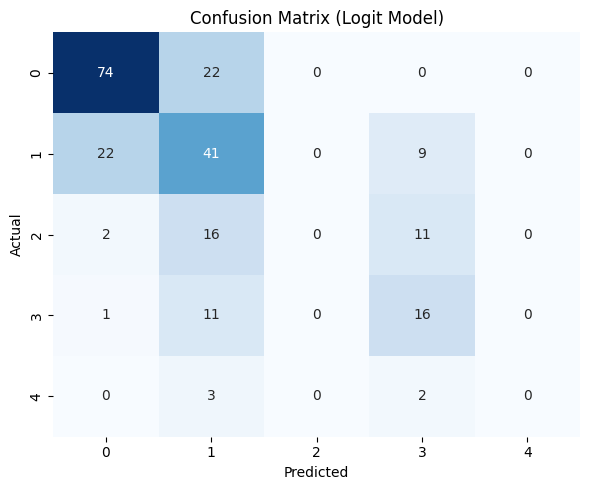

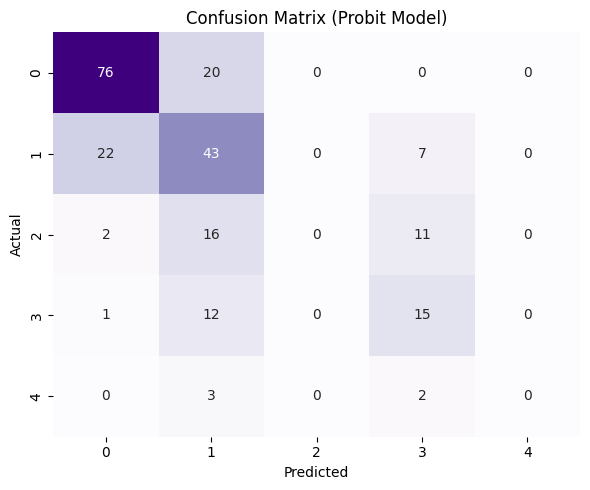

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix for logit model
cm_logit = confusion_matrix(y_test, y_multi_class)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_logit, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix (Logit Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Confusion matrix for probit model
cm_probit = confusion_matrix(y_test, y_multi_pro_class)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_probit, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title("Confusion Matrix (Probit Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

Alarming Classification Report

In [ ]:
from sklearn.utils import resample

# Combine X and y for resampling
train_df = X_train.copy()
train_df['num'] = y_train

# Upsample class 4
df_class_4 = train_df[train_df['num'] == 4]
df_upsampled = resample(df_class_4,
                        replace=True,
                        n_samples=30,  # Try to match other class sizes
                        random_state=42)

# Combine back
train_df_balanced = pd.concat([train_df, df_upsampled])
X_train_bal = train_df_balanced.drop(['num','dataset_Switzerland', 'slope_upsloping','thal_reversable defect','restecg_normal','fbs','age'], axis=1)
y_train_bal = train_df_balanced['num']

X_test= X_test.drop(['dataset_Switzerland', 'slope_upsloping','thal_reversable defect','restecg_normal','fbs','age'], axis = 1)

modelBalanced = OrderedModel(y_train_bal, X_train_bal, distr='logit')

resultBalanced = modelBalanced.fit(method='bfgs')

# Predict probabilities
y_balanced_prob= resultBalanced.predict(X_test)

# Get most likely class
y_balanced_pred = y_balanced_prob.idxmax(axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_balanced_pred))
print(classification_report(y_test, y_balanced_pred))

NameError: name 'X_train' is not defined

Fixing, ReSampling

Optimization terminated successfully.
         Current function value: 1.170805
         Iterations: 69
         Function evaluations: 74
         Gradient evaluations: 74
                             OrderedModel Results                             
Dep. Variable:                    num   Log-Likelihood:                -1844.0
Model:                   OrderedModel   AIC:                             3726.
Method:            Maximum Likelihood   BIC:                             3828.
Date:                Wed, 07 May 2025                                         
Time:                        01:20:09                                         
No. Observations:                1575                                         
Df Residuals:                    1556                                         
Df Model:                          15                                         
                               coef    std err          z      P>|z|      [0.025      0.975]
------------------------

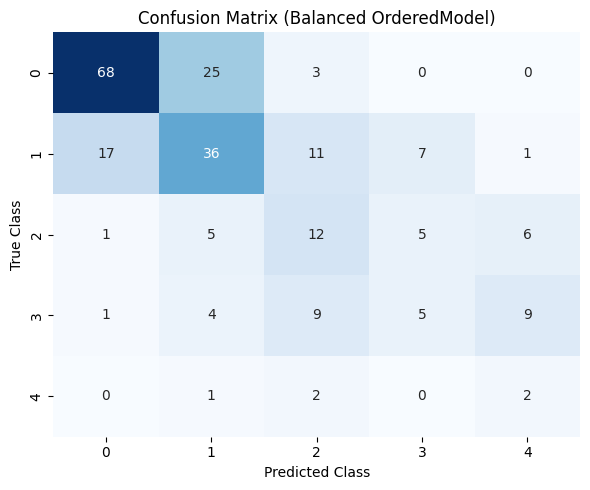

In [ ]:
import pandas as pd
import numpy as np
from sklearn.utils import resample
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import classification_report, confusion_matrix
from scipy import stats

# Step 1: Combine training features and target
train_data = pd.concat([X_train, y_train], axis=1)

# Step 2: Find the maximum class size (most common class)
max_class_size = train_data['num'].value_counts().max()

# Step 3: Upsample each class to match the majority size
upsampled_classes = []
for label in train_data['num'].unique():
    class_df = train_data[train_data['num'] == label]
    upsampled_df = resample(class_df,
                            replace=True,
                            n_samples=max_class_size,
                            random_state=42)
    upsampled_classes.append(upsampled_df)

# Step 4: Combine upsampled data and shuffle
train_balanced = pd.concat(upsampled_classes)
train_balanced = train_balanced.sample(frac=1, random_state=42)

# Step 5: Define features to drop (to match X_test)
features_to_drop = ['num', 'dataset_Switzerland', 'slope_upsloping',
                    'thal_reversable defect', 'restecg_normal', 'fbs', 'age']

# Step 6: Split features and target for training
X_train_bal = train_balanced.drop(columns=features_to_drop)
y_train_bal = train_balanced['num']

# Step 7: Drop same features from test set
X_test_bal = X_test.drop(columns=features_to_drop[1:], errors='ignore')  # don't drop 'num' in test

# Step 8: Fit OrderedModel
model_bal = OrderedModel(y_train_bal, X_train_bal, distr=stats.gumbel_r)
result_bal = model_bal.fit(method='bfgs', maxiter=1000)

print(result_bal.summary())

# Step 9: Predict on test set
y_probs_bal = result_bal.predict(X_test_bal)
y_pred_bal = y_probs_bal.idxmax(axis=1)

# Step 10: Evaluate
print("Classification Report (Fully Balanced):")
print(classification_report(y_test, y_pred_bal))

cm = confusion_matrix(y_test, y_pred_bal)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix (Balanced OrderedModel)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()
